# "From-scratch" regional simulation with biogeochemistry (template)
This notebook serves as a **template** with everything needed to create a simulation of any geographic region from scratch, including the creation of model setting files, compilation, and running of the model. **It does not go into detail** about these steps, and should serve more as a tool for quickly prototyping ROMS configurations. For more detailed descriptions of the steps taken here, as well as more advanced applications, see the tutorial on nested simulations with carbon dioxide removal interventions, where a pre-defined configuration is already provided and walked through. Additionally, further details on generating ROMS input files using python (as is done here) can be found in the `roms-tools` [documentation](https://roms-tools.readthedocs.io/).

To use this notebook interactively, copy it from `$ROMS_ROOT/docs/tutorials/from_scratch_bgc_simulation.ipynb` to the directory in which your simulation is to be configured.

## Requirements
This notebook requires an install of the `roms-tools` and `f90nml` python packages, as well as `jupyter` to run this page as a notebook. Additionally, a selection of datasets are required to use `roms-tools`. For more information on these datasets, see the corresponding `roms-tools` [documentation page](https://roms-tools.readthedocs.io/en/latest/datasets.html). The first cell below sets paths to these datasets once they have been downloaded. If you adjust it to point to your own copies of these data, the rest of the notebook should run.

To use this notebook interactively, simply copy it to any directory where you wish to configure a ROMS simulation and adjust the below cell.

**This cell imports dependencies and sets paths to required datasets:**

In [1]:
%matplotlib inline
import os
from pathlib import Path
sim_dir=Path(os.getenv("ROMS_ROOT")+"/Examples/from_scratch")
sim_dir.mkdir(parents=True,exist_ok=True)
os.chdir(sim_dir)

import roms_tools as rt
from pathlib import Path
import datetime as dt
import f90nml

# ROMS tools source data:
rtd=Path("~/Code/roms_tools_datasets")

topo_path = rtd/"SRTM15_V2.5.nc" # Topography (SRTM15)
era5_path = [rtd/"ERA5_2012-01.nc", rtd/"ERA5_2012-02.nc"] # Surface forcing (ERA5)
glorys_paths = [rtd/f"GLORYS/mercatorglorys12v1_gl12_mean_201201{d:02}.nc" for d in range(1,32)][:-2] # Interior state for initial and boundary conditions (GLORYS)

# Set if your run will include tides
tpxo_path = rtd/"TPXO10.v2/" # Tidal forcing (TPXO)\

# Set if your run will include biogeochemistry:
bgc_path = rtd/"BGC/BGCdataset.nc" # BGC tracers for initial and boundary conditions (CWorthy unified BGC dataset)
bgc_surf_path = rtd/"BGC/BGCdataset.nc" # BGC surface forcing (CWorthy unified BGC dataset)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


**This cell sets up the current directory up for our simulation:**

In [2]:
%%bash
mkdir input_data
mkdir output
cp $ROMS_ROOT/Work/Makefile .
cp $ROMS_ROOT/src/marbl_in .

## General Parameters
**This cell sets as variables all the parameters we may wish to set for our simulation, for re-use later. Change it as required. More information about model settings can be found at the corresponding pages in this documentation.**

In [3]:
# Domain, resolution, and parallel processing:
DOMAIN_N_LEVELS = 10
DOMAIN_N_X_POINTS = 96
DOMAIN_N_Y_POINTS = 96
N_PROCESSORS_X = 3
N_PROCESSORS_Y = 3

# Simulation timing
SIMULATION_START_TIME = dt.datetime(2012,1,1,12,0,0)
SIMULATION_END_TIME = dt.datetime(2012,1,10,0,0,0)
SIMULATION_TIME_STEP = 360 #seconds

# Simulation options
INCLUDE_TIDES = True
INCLUDE_RIVERS = True
INCLUDE_BIOGEOCHEMISTRY = True

# Output controls
OUTPUT_FREQUENCY = 86400 # (seconds)
OUTPUT_TYPE = "snapshot" # ("average" or "snapshot")
RESTART_FREQUENCY = 86400 * 5 # (seconds) How often to create a model restart file

INCLUDE_BIOGEOCHEMISTRY_OUTPUT = True # Include the ~31 BGC tracers in the output
INCLUDE_BIOGEOCHEMISTRY_DIAGNOSTIC_OUTPUT = True # Include ~300 BGC-related diagnostic fields in the output
INCLUDE_PHYSICS_OUTPUT = True # Include the physical state variables (u,v,w,T,S) in the output

In [4]:
# Initializing some other variables we will use:

forcing_paths = [] # List of paths to the model forcing files we will create
output_paths = {}  # Dictionary of all output paths (incl. grid and initial conditions, not just forcing)

In [5]:
# Initializing ROMS namelist and cpp key list
roms_root_dir = Path(os.getenv("ROMS_ROOT"))
roms_namelist = f90nml.read(roms_root_dir/"src/namelist.nml")

**The below cells create netCDF and compile-time configuration files for our simulation:**

## Creating a model grid
**This cell sets up the simulation domain. It is the only remaining cell you should need to edit to customize your run:**

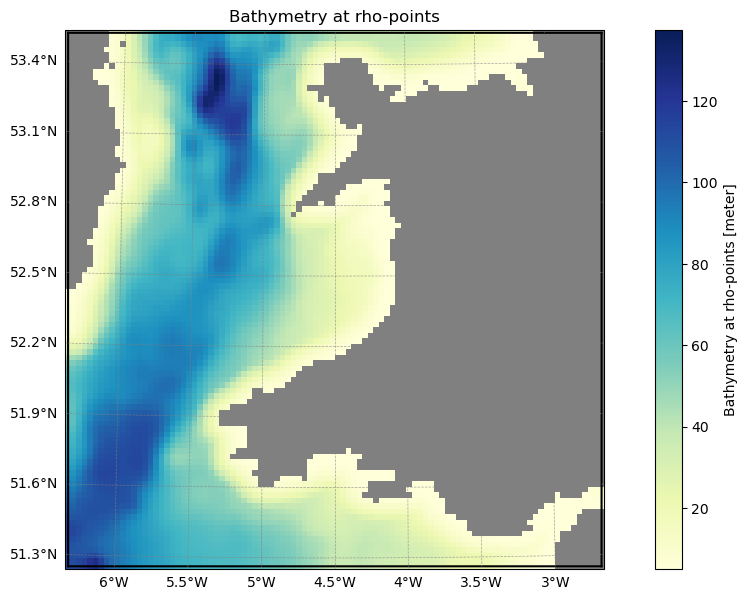

In [6]:
grid = rt.Grid(
                        N  = DOMAIN_N_LEVELS,        # Vertical levels
                        nx = DOMAIN_N_X_POINTS,      # Points in x direction
                        ny = DOMAIN_N_Y_POINTS,      # Points in y direction
                        size_x = 250,                # Geographic extent of the domain in x (km)
                        size_y = 250,                # Geographic extent of the domain in y (km)
                        center_lon = -4.5,           # Center longitude
                        center_lat = 52.4,            # Center latitude
                        rot = 0,                      # Rotation
                        topography_source = {         # Source topography data
                            "name": "SRTM15",
                            "path": str(topo_path),
                        }
                    )
grid.plot()

In [7]:
# Save grid data
grid_path    = grid.save("input_data/grid.nc")
roms_namelist["GRID_SETTINGS"]["grdname"] = str(grid_path[0])

2026-05-05 20:14:52 - INFO - Writing the following NetCDF files:
input_data/grid.nc


## Creating bulk forcing

In [8]:
# Physical surface forcing
surface_bulk_forcing = rt.SurfaceForcing(
    grid = grid,
    start_time = SIMULATION_START_TIME,
    end_time = SIMULATION_END_TIME,
    type= "physics",
    source={"name": "ERA5", "path": era5_path},
    use_dask=True,
)

2026-05-05 20:14:54 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bulk_frc.opt` ROMS option file.


In [9]:
# Save to netCDF
surface_bulk_forcing_path = surface_bulk_forcing.save("input_data/surface_bulk_forcing.nc", group=False)

2026-05-05 20:15:07 - INFO - Writing the following NetCDF files:
input_data/surface_bulk_forcing.nc


[########################################] | 100% Completed | 27.35 s


**This cell updates bulk-forcing-related parameters in the ROMS namelist:**

In [10]:
roms_namelist["FORCING_FILES"]["frcfile"]=[]
roms_namelist["FORCING_FILES"]["frcfile"].extend([str(p) for p in surface_bulk_forcing_path])
roms_namelist["BULK_FRC_SETTINGS"]["interp_bulk_frc"] = surface_bulk_forcing.use_coarse_grid

## Creating BGC forcing
**This cell generates biogeochemical surface forcing using `roms-tools`**:

In [11]:
if INCLUDE_BIOGEOCHEMISTRY:
    # BGC surface forcing
    surface_bgc_forcing = rt.SurfaceForcing(
        grid=grid,
        start_time = SIMULATION_START_TIME,
        end_time   = SIMULATION_END_TIME,
        source     ={
            "name": "UNIFIED", 
            "path": bgc_surf_path, 
            "climatology":True
        },
        type="bgc",
        use_dask=True,
    )
    surface_bgc_forcing_path = surface_bgc_forcing.save("input_data/bgc_surface_forcing.nc", group=False)
    forcing_paths.extend([str(p) for p in surface_bgc_forcing_path])

2026-05-05 20:15:37 - WARNING - Optional variables missing (but not critical): ['pco2_air_alt']
2026-05-05 20:15:37 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bgc.opt` ROMS option file.
2026-05-05 20:15:37 - INFO - Writing the following NetCDF files:
input_data/bgc_surface_forcing.nc


[########################################] | 100% Completed | 414.60 ms


**This cell updates bulk-forcing-related parameters in the ROMS namelist:**

In [12]:
roms_namelist["FORCING_FILES"]["frcfile"].extend([str(p) for p in surface_bgc_forcing_path])
roms_namelist["BGC_SETTINGS"]["interp_bgc_frc"] = surface_bgc_forcing.use_coarse_grid

## Creating boundary forcing
**This cell generates boundary forcing file using `roms-tools` and adds the file to the ROMS namelist:**

In [13]:
boundary_phys_forcing = rt.BoundaryForcing(
    grid       = grid,
    start_time = SIMULATION_START_TIME,
    end_time   = SIMULATION_END_TIME,
    source={
        "name": "GLORYS", 
        "path": glorys_paths
    },
    type = "physics",  # "physics" or "bgc"; default is "physics"
    use_dask = True,
    apply_2d_horizontal_fill = True
)
boundary_phys_forcing_path = boundary_phys_forcing.save("input_data/phys_boundary_forcing.nc",group=False)
roms_namelist["FORCING_FILES"]["frcfile"].extend([str(p) for p in boundary_phys_forcing_path])

if INCLUDE_BIOGEOCHEMISTRY:
    boundary_bgc_forcing = rt.BoundaryForcing(
        grid       = grid,
        start_time = SIMULATION_START_TIME,
        end_time   = SIMULATION_END_TIME,
        source={
            "name": "UNIFIED", 
            "path": bgc_path, 
            "climatology": True
        },
        type="bgc",
        use_dask=True,
        apply_2d_horizontal_fill = True
    )
    
    boundary_bgc_forcing_path  = boundary_bgc_forcing.save("input_data/bgc_boundary_forcing.nc",group=False)
    roms_namelist["FORCING_FILES"]["frcfile"].extend([str(p) for p in boundary_bgc_forcing_path])


2026-05-05 20:15:37 - INFO - No `boundaries` provided. Using mask-based defaults: {'south': True, 'east': True, 'north': True, 'west': True}
2026-05-05 20:15:37 - WARNING - No records found before the start_time: 2012-01-01 12:00:00.
2026-05-05 20:15:41 - INFO - Writing the following NetCDF files:
input_data/phys_boundary_forcing.nc


[                                        ] | 0% Completed | 127.42 us

/Users/dafyddstephenson/Code/roms-tools/roms_tools/utils.py:916: UserWarning: Unlimited dimension(s) {'time'} declared in 'dataset.encoding', but not part of current dataset dimensions. Consider removing {'time'} from 'dataset.encoding'.
  xr.save_mfdataset(dataset_list, output_filenames)


[########################################] | 100% Completed | 7.23 ss


2026-05-05 20:15:48 - INFO - No `boundaries` provided. Using mask-based defaults: {'south': True, 'east': True, 'north': True, 'west': True}
2026-05-05 20:15:48 - WARNING - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']
2026-05-05 20:15:49 - INFO - Writing the following NetCDF files:
input_data/bgc_boundary_forcing.nc
/Users/dafyddstephenson/Code/roms-tools/roms_tools/utils.py:916: UserWarning: Unlimited dimension(s) {'time'} declared in 'dataset.encoding', but not part of current dataset dimensions. Consider removing {'time'} from 'dataset.encoding'.
  xr.save_mfdataset(dataset_list, output_filenames)


[########################################] | 100% Completed | 7.49 sms


## Creating river forcing
**This cell generates river forcing files using `roms-tools`:**

2026-05-05 20:15:58 - INFO - No river indices provided. Identify all rivers within the ROMS domain and assign each of them to the nearest coastal point.
2026-05-05 20:15:59 - INFO - Compute climatology for river forcing.
2026-05-05 20:15:59 - INFO - Writing the following NetCDF files:
input_data/river_forcing.nc


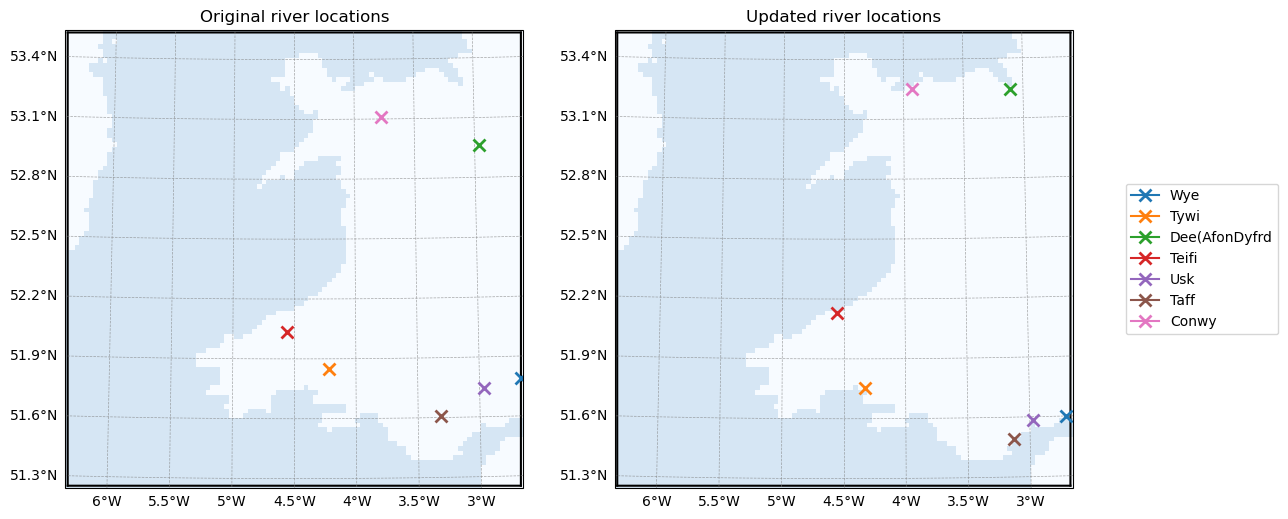

In [14]:
if INCLUDE_RIVERS:
    river_forcing = rt.RiverForcing(
        grid        = grid,
        start_time  = SIMULATION_START_TIME,
        end_time    = SIMULATION_END_TIME,
        include_bgc = INCLUDE_BIOGEOCHEMISTRY,
    )
    river_forcing.plot_locations()
    river_forcing_path = river_forcing.save("input_data/river_forcing.nc")
    

**This cell updates river-related parameters in the ROMS namelist:**

In [15]:
if INCLUDE_RIVERS:
    roms_namelist["RIVER_FRC_SETTINGS"]["river_source"]=True
    roms_namelist["RIVER_FRC_SETTINGS"]["nriv"]=river_forcing.ds.sizes.get("nriver")
    roms_namelist["FORCING_FILES"]["frcfile"].extend([str(p) for p in river_forcing_path])

## Creating tidal forcing
**This cell generates tidal forcing files using `roms-tools`:**

[########################################] | 100% Completed | 414.68 ms


2026-05-05 20:16:22 - INFO - Writing the following NetCDF files:
input_data/tides.nc


[########################################] | 100% Completed | 18.49 s


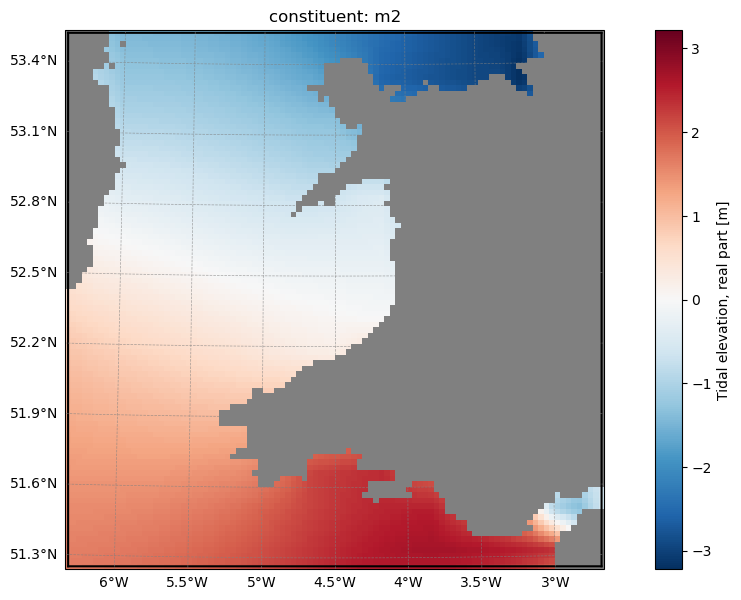

In [16]:
if INCLUDE_TIDES:
    tidal_forcing = rt.TidalForcing(
        grid=grid,
        source={"name": "TPXO", "path": 
                    {
                    "grid": tpxo_path / "grid_tpxo10v2.nc",
                    "h": tpxo_path / "h_tpxo10.v2.nc",
                    "u": tpxo_path / "u_tpxo10.v2.nc",
                    }
               },
        ntides=10, # Number of tidal constituents
        use_dask=True
    )
    tidal_forcing.plot("ssh_Re", ntides=0)
    tidal_forcing_path = tidal_forcing.save("input_data/tides.nc")

**This cell updates the tidal settings in the ROMS namelist:**

In [17]:
if INCLUDE_TIDES:
    roms_namelist["TIDES_SETTINGS"]["ntides"]=tidal_forcing.ds.sizes.get("ntides")
    roms_namelist["TIDES_SETTINGS"]["pot_tides"]=True
    roms_namelist["FORCING_FILES"]["frcfile"].extend([str(p) for p in tidal_forcing_path])

 ## Creating initial Conditions
 **This cell generates initial conditions from GLORYS reanalysis using `roms-tools` and adds the file to the ROMS namelist:**

In [18]:
if INCLUDE_BIOGEOCHEMISTRY:
    bgc_source = {
            "name": "UNIFIED",
            "path": bgc_path,
            "climatology": True,
            }
else:
    bgc_source=None

initial_conditions = rt.InitialConditions(
    grid     = grid,
    ini_time = SIMULATION_START_TIME,
    source={"name": "GLORYS", "path": glorys_paths[0]},
    bgc_source = bgc_source,
    use_dask = True,
    allow_flex_time = True # Move the initialization time to the nearest available GLORYS data
)

initial_conditions_path = initial_conditions.save("input_data/initial_conditions.nc")
roms_namelist["INITIAL_CONDITIONS"]["ininame"] = str(initial_conditions_path[0])

2026-05-05 20:16:41 - WARNING - Selected time entry closest to the specified start_time in +24 hour range: ['2012-01-01T12:00:00.000000000']
2026-05-05 20:16:42 - WARNING - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']
2026-05-05 20:16:42 - INFO - Writing the following NetCDF files:
input_data/initial_conditions.nc


[########################################] | 100% Completed | 1.13 sms


## Other ROMS settings
These cells update anything else specified in the top configuration cell in the ROMS namelist
### Output settings

In [19]:
roms_namelist["SIMULATION_NAME_SETTINGS"]["output_root_name"] = "output/roms"

roms_namelist["BASIC_OUTPUT_SETTINGS"]["wrt_file_his"] = True if (INCLUDE_PHYSICS_OUTPUT and OUTPUT_TYPE=="snapshot") else False
roms_namelist["BASIC_OUTPUT_SETTINGS"]["wrt_file_avg"] = True if (INCLUDE_PHYSICS_OUTPUT and OUTPUT_TYPE=="average") else False
roms_namelist["BASIC_OUTPUT_SETTINGS"]["output_period_rst"] = RESTART_FREQUENCY
roms_namelist["BASIC_OUTPUT_SETTINGS"]["output_period_his"] = OUTPUT_FREQUENCY
roms_namelist["BASIC_OUTPUT_SETTINGS"]["output_period_avg"] = OUTPUT_FREQUENCY

if INCLUDE_BIOGEOCHEMISTRY:
    roms_namelist["BGC_SETTINGS"]["wrt_bgc_his"] = True if (INCLUDE_BIOGEOCHEMISTRY_OUTPUT and OUTPUT_TYPE=="snapshot") else False
    roms_namelist["BGC_SETTINGS"]["wrt_bgc_avg"] = True if (INCLUDE_BIOGEOCHEMISTRY_OUTPUT and OUTPUT_TYPE=="average") else False
    roms_namelist["BGC_SETTINGS"]["wrt_bgc_dia_his"] = True if (INCLUDE_BIOGEOCHEMISTRY_DIAGNOSTIC_OUTPUT and OUTPUT_TYPE=="snapshot") else False
    roms_namelist["BGC_SETTINGS"]["wrt_bgc_dia_avg"] = True if (INCLUDE_BIOGEOCHEMISTRY_DIAGNOSTIC_OUTPUT and OUTPUT_TYPE=="average") else False

    roms_namelist["BGC_SETTINGS"]["output_period_his"] = OUTPUT_FREQUENCY
    roms_namelist["BGC_SETTINGS"]["output_period_avg"] = OUTPUT_FREQUENCY
    roms_namelist["BGC_SETTINGS"]["output_period_his_dia"] = OUTPUT_FREQUENCY
    roms_namelist["BGC_SETTINGS"]["output_period_avg_dia"] = OUTPUT_FREQUENCY    

### Grid- and parallelization-related settings

In [20]:
roms_namelist["PARAM_SETTINGS"]["LLm"   ] = DOMAIN_N_X_POINTS
roms_namelist["PARAM_SETTINGS"]["MMm"   ] = DOMAIN_N_Y_POINTS
roms_namelist["PARAM_SETTINGS"]["N"     ] = DOMAIN_N_LEVELS
roms_namelist["PARAM_SETTINGS"]["NP_XI" ] = N_PROCESSORS_X
roms_namelist["PARAM_SETTINGS"]["NP_ETA"] = N_PROCESSORS_Y
if INCLUDE_BIOGEOCHEMISTRY:
    roms_namelist["PARAM_SETTINGS"]["ntrc_bio"] = 32 # No. of BGC tracers
    
# Vertical co-ordinate parameters
roms_namelist["S_COORD"      ]["theta_s"] = grid.theta_s
roms_namelist["S_COORD"      ]["theta_b"] = grid.theta_b
roms_namelist["S_COORD"      ]["hc"     ] = grid.hc

### Time step settings

In [21]:
# Time-stepping and s-coord
roms_namelist["TIME_STEPPING"]["dt"    ] = SIMULATION_TIME_STEP
roms_namelist["TIME_STEPPING"]["ntimes"] = int((SIMULATION_END_TIME-SIMULATION_START_TIME).total_seconds()/SIMULATION_TIME_STEP)

### Save all runtime settings to file

In [22]:
roms_namelist.write("namelist.nml")

### Compile-time settings
**This cell creates an options file (`cppdefs.opt`) for pre-compilation of ROMS, defining "on-off" switches for model features.**

For more information on the `cppdefs.opt` file, see the corresponding documentation page

In [23]:
# Open and read default cppdefs.opt file
with open(roms_root_dir/"src/cppdefs.opt") as F:
    lines=F.readlines()

# Append keys for our simulation (potentially duplicating but overriding keys defined above):
lines.append("!!!!!!!!!!!!!!!!!!!!!!!!! FROM-SCRATCH EXAMPLE NOTEBOOK !!!!!!!!!!!!!!!!!!!!!!!!!")
lines.append("#define MARBL" if INCLUDE_BIOGEOCHEMISTRY else "#undef MARBL")
lines.append("#define RIVER_SOURCE" if INCLUDE_RIVERS else "#undef RIVER_SOURCE")
lines.append("#define TIDES" if INCLUDE_TIDES else "#undef TIDES")
lines.append("#define MARBL_DIAGS" if INCLUDE_BIOGEOCHEMISTRY_DIAGNOSTIC_OUTPUT else "#undef MARBL_DIAGS")

# Write our modified copy
with open("cppdefs.opt","w") as F:
    for L in lines:
        F.write(L.strip()+"\n")

## Compiling the model

In [ ]:
%%bash
make compile_clean
make

_(Cell output hidden due to length)_

## Pre-processing the input data
**The below cells "partition" the input files such that each processor receives one subset of the domain**

In [ ]:
for p in Path("input_data").glob("*.nc"):
    !cd input_data; partit {N_PROCESSORS_X} {N_PROCESSORS_Y} {str(p.name)} 

_(Cell output hidden due to length)_

## Running the model
The below cell was run on a laptop using an environment configured by conda from `$ROMS_ROOT/environments/conda_environment.yml`. Depending on your environment/system, this command may differ (e.g. `mpiexec` or `srun`), and on HPC systems will likely need to be added to a script that is submitted to a job scheduler such as SLURM or PBS. Consult your system's documentation for more information. 

In [ ]:
!mpirun -n {N_PROCESSORS_X*N_PROCESSORS_Y} ./roms namelist.nml

_(Cell output hidden due to length)_

## Post-processing model output data
**The below cell "joins" the output files, which were generated separately on different subdomains by each processor**

In [ ]:
%%bash
cd output
# We want to loop over the filename stems, so we'll use the `.0.nc` files as a template
for F in *.0.nc;do

    # Get filename stem, e.g.
    # output/roms_bgc.20120101120000.0.nc -> output/roms_bgc.20120101120000
    filename_stem=${F/.0.nc}

    # Skip any `_ext` files, to be addressed separately:
    if [[ "${filename_stem}" == *"_ext."* ]]; then
        continue
    fi

    # wildcard to join all subdomains with this stem
    ncjoin ${filename_stem}.?.nc
done

_(Cell output hidden due to length)_

## Visualizing model output
**The below cell demonstrates that the model has successfully run and produced output, comparing the first and final records in an output file**

If you chose not to output snapshots of model physics above, you will need to change the file path to another output file:

In [28]:
ls output/roms_*.??????????????.nc

output/roms_bgc.20120101120000.nc      output/roms_his.20120101120000.nc
output/roms_bgc_dia.20120101120000.nc


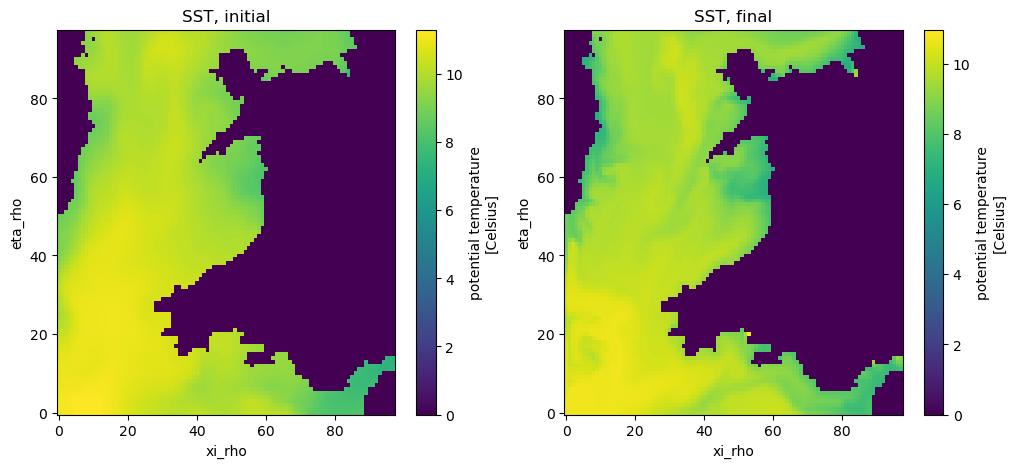

In [29]:
import xarray as xr
import matplotlib.pyplot as plt
DS=xr.open_dataset("output/roms_his.20120101120000.nc")
fig,ax=plt.subplots(1,2)
DS.temp.isel(s_rho=-1,time=0).plot(ax=ax[0]) # s_rho is the vertical co-ordinate, reverse indexed (0 at the bottom, -1 at the surface)
ax[0].set_title("SST, initial")
DS.temp.isel(s_rho=-1,time=-1).plot(ax=ax[1])
ax[1].set_title("SST, final")
fig.set_size_inches(12,5)

## Summary
This tutorial has gone through all of the steps necessary to create and run a ROMS simulation with physics and biogeochemistry, including river and tidal forcing. Rather than going through each step in detail, it is provided as a template to create custom configurations. For more details on each of the steps here, see ROMS' other tutorial on nested simulations with CDR, which acts as a walkthrough for a pre-defined series of simulations, rather than a simpler, customizable notebook.

